# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [87]:
#1 Imports and Warnings Suppression

In [115]:
import requests
from bs4 import BeautifulSoup
from newspaper import Article
from youtube_transcript_api import YouTubeTranscriptApi
from iText2KG.itext2kg.documents_distiller import DocumentsDistiller, CV
import yaml
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.caches import BaseCache
from pydantic import BaseModel
from langchain_core.callbacks.base import Callbacks
from typing import List
from iText2KG.itext2kg import iText2KG
import networkx as nx
import matplotlib as plt
from langchain.text_splitter import RecursiveCharacterTextSplitter
import time
import warnings
from langchain_ollama import ChatOllama, OllamaEmbeddings
from neo4j_client import Neo4jClient

from langchain_core.caches import BaseCache
from langchain_ollama import ChatOllama

ChatOllama.BaseCache = BaseCache
ChatOllama.model_rebuild()

# Suppress Pydantic schema warning
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic._internal._generate_schema")

ChatOpenAI.BaseCache = BaseCache
ChatOpenAI.model_rebuild()


In [116]:
#2 Article Scraping Function 

In [117]:
def scrape_article(url):
    print(f"Scraping article from: {url}")

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }

    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        # Method 1: BeautifulSoup approach
        soup = BeautifulSoup(response.text, 'html.parser')
        content_div = soup.find("div", class_="entry-content ap-pattern--entry-content")

        if content_div:
            article_text = content_div.get_text(separator="\n", strip=True)
            with open("output/pure_scrum_clean.txt", "w", encoding="utf-8") as f:
                f.write(article_text)
            print("Article scraped successfully with BeautifulSoup")
        else:
            print("Specific div not found, trying newspaper3k...")

        # Method 2: Newspaper3k approach (as backup)
        article = Article(url)
        article.download()
        article.parse()

        if article.text:
            with open("output/pure_scrum_clean2.txt", "w", encoding="utf-8") as f:
                f.write(article.text)
            print("Article scraped successfully with newspaper3k")
            return article.text
        else:
            print("Failed to extract article content")
            return None

    except requests.RequestException as e:
        print(f"Error fetching article: {e}")
        return None

In [118]:
#3. YouTube Transcript Retrieval Function

In [119]:
def get_youtube_transcript(video_id):
    print(f"Getting YouTube transcript for video: {video_id}")

    try:
        transcript_list = YouTubeTranscriptApi.get_transcript(video_id)
        transcript = " ".join([item['text'] for item in transcript_list])

        with open("output/youtubeVideo.txt", "w", encoding="utf-8") as f:
            f.write(transcript)

        print("YouTube transcript downloaded successfully")
        return transcript

    except Exception as e:
        print(f"Error getting YouTube transcript: {e}")
        return None

In [120]:
#4. Configuration Loading

In [121]:
def load_config(config_path="config.yml"):
    try:
        with open(config_path, "r") as f:
            config = yaml.safe_load(f)
        return config
    except FileNotFoundError:
        print("config.yml not found. Creating sample config for Ollama...")

        sample_config = {
            'llm': {
                'model_type': 'ollama',
                'model_name': 'gemma3',
                'temperature': 0.7,
                'max_tokens': 2000,
                'timeout': 60,
                'max_retries': 3
            },
            'paths': {
                'output_dir': './output'
            }
        }

        with open(config_path, "w") as f:
            yaml.dump(sample_config, f, default_flow_style=False)

        print("Sample config.yml created. Update it if needed.")
        return sample_config


In [122]:
#5. LLM and Embeddings Initialization

In [123]:
# import os
# 
# 
# def initialize_llm(config):
#     if not config:
#         return None, None
#     
#     llm_config = config.get('llm', {})
#     api_key = llm_config.get('api_key')
#     
#     if not api_key:
#         api_key = os.getenv('OPENAI_API_KEY')
#         if not api_key:
#             print("OpenAI API key not found. Please set OPENAI_API_KEY environment variable or update config.yml")
#             return None, None
#     
#     try:
#         if llm_config.get('model_type') == "openai":
#             llm = ChatOpenAI(
#                 model=llm_config.get('model_name', 'gpt-3.5-turbo'),
#                 temperature=llm_config.get('temperature', 0.7),
#                 max_tokens=llm_config.get('max_tokens', 2000),
#                 api_key=api_key,
#                 request_timeout=llm_config.get('timeout', 60),
#                 max_retries=llm_config.get('max_retries', 3)
#             )
#             embeddings = OpenAIEmbeddings(api_key=api_key)
#             print("LLM and Embeddings initialized successfully")
#             return llm, embeddings
#         else:
#             print("Only 'openai' model type is supported")
#             return None, None
#     except Exception as e:
#         print(f"Error initializing LLM: {e}")
#         return None, None
#     

In [124]:
#5.1 Ollama

In [125]:

def initialize_llm(config):
    if not config:
        return None, None

    llm_config = config.get('llm', {})

    try:
        if llm_config.get('model_type') == "ollama":
            llm = ChatOllama(
                model=llm_config.get('model_name', 'llama2'),
                temperature=llm_config.get('temperature', 0.7)
            )

            embeddings = OllamaEmbeddings(model=llm_config.get('model_name', 'llama2'))

            print("LLM and Embeddings initialized successfully (Ollama)")
            return llm, embeddings
        else:
            print("Only 'ollama' model type is supported in this setup")
            return None, None
    except Exception as e:
        print(f"Error initializing LLM: {e}")
        return None, None


In [126]:
#6. Pydantic Models for Triples

In [127]:
class Triple(BaseModel):
    subject: str
    predicate: str
    object: str


class TriplesOutput(BaseModel):
    triples: List[Triple]


In [128]:
#7. Knowledge Graph Extraction Function with Retry

In [129]:
def simple_kg_extraction(text, llm, limit=8, max_retries=3):
    if not llm:
        print("LLM not initialized")
        return []

    prompt_template = """
Extract key knowledge graph triples from the following text.
Only return triples in the form (subject, predicate, object).
Focus on important entities and relationships. Avoid duplicates.
Output each triple on its own line with this exact format:
- (Entity1, relationship, Entity2)

Text: {input_text}

Return up to {limit} triples.
"""

    text_to_use = text[:1500]

    for attempt in range(max_retries):
        prompt = prompt_template.format(input_text=text_to_use, limit=limit)

        try:
            response = llm.invoke(prompt)
            lines = response.content.split('\n')
            triples = []

            for line in lines:
                line = line.strip()
                if line.startswith('-') and '(' in line and ')' in line:
                    start = line.find('(')
                    end = line.find(')')
                    if start != -1 and end != -1:
                        triple_str = line[start + 1:end]
                        parts = [part.strip() for part in triple_str.split(',')]
                        if len(parts) == 3:
                            triples.append((parts[0], parts[1], parts[2]))

            return triples

        except Exception as e:
            error_msg = str(e).lower()

            if "rate limit" in error_msg or "429" in error_msg:
                wait_time = (2 ** attempt) * 10
                print(f"Rate limit hit (attempt {attempt + 1}/{max_retries}). Waiting {wait_time}s...")
                time.sleep(wait_time)

            elif "token" in error_msg:
                print(f"Token limit exceeded. Reducing text size and retrying...")
                text_to_use = text_to_use[:len(text_to_use) // 2]
                limit = max(3, limit // 2)
                time.sleep(5)

            else:
                print(f"Error in KG extraction (attempt {attempt + 1}/{max_retries}): {e}")
                time.sleep(5)

    print(f"Failed to extract triples after {max_retries} attempts")
    return []


In [130]:
#8. Process Text in Chunks to Avoid Rate Limits

In [131]:
def process_text_in_chunks(text, llm, chunk_size=1000, chunk_overlap=50, delay_between_chunks=0):
    print(f"Processing text in chunks...")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = splitter.split_text(text)

    print(f"Created {len(chunks)} chunks")

    all_triples = []

    for i, chunk in enumerate(chunks, 1):
        limit = max(5, len(chunk) // 150)
        print(f"\nProcessing chunk {i}/{len(chunks)} with triple limit {limit}")

        triples = simple_kg_extraction(chunk, llm, limit=limit)
        if triples:
            all_triples.extend(triples)
            print(f"Chunk {i} → {len(triples)} triples extracted")
        else:
            print(f"Chunk {i} → No triples extracted")

        if i < len(chunks) and delay_between_chunks > 0:
            print(f"Waiting {delay_between_chunks}s before next chunk...")
            time.sleep(delay_between_chunks)

    return all_triples


In [132]:
#8. Save Triples to File and also filter duplicates

In [133]:
def normalize_triples(triples):
    return [(s.strip().lower(), p.strip().lower(), o.strip().lower()) for s, p, o in triples]


def filter_triples(triples):
    filtered = []
    for subj, pred, obj in triples:
        if subj and pred and obj and subj.lower() != 'none' and obj.lower() != 'none':
            filtered.append((subj, pred, obj))
    return filtered


def remove_duplicates(triples):
    seen = set()
    unique_triples = []
    for triple in triples:
        if triple not in seen:
            unique_triples.append(triple)
            seen.add(triple)
    return unique_triples


def save_triples(triples, filename="extracted_triples.txt"):
    with open(filename, "w", encoding="utf-8") as f:
        f.write("Extracted Knowledge Graph Triples:\n")
        f.write("=" * 40 + "\n\n")
        for i, (subject, predicate, obj) in enumerate(triples, 1):
            f.write(f"{i}. ({subject}) --[{predicate}]--> ({obj})\n")

    print(f"Triples saved to {filename}")


In [134]:
#11. Plots

In [135]:
import networkx as nx
import matplotlib.pyplot as plt


def plot_triples(triples):
    G = nx.DiGraph()
    for subj, pred, obj in triples:
        G.add_node(subj)
        G.add_node(obj)
        G.add_edge(subj, obj, label=pred)

    pos = nx.spring_layout(G, k=0.5, iterations=50)

    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, font_size=10, arrowsize=20)

    edge_labels = {(subj, obj): pred for subj, pred, obj in triples}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)

    plt.title("Knowledge Graph Visualization")
    plt.show()


In [136]:
#9. Main Execution Logic

In [152]:
import re
def main():
    print("Starting Knowledge Graph Extraction Pipeline\n")

    # Scrape article
    # url = "https://age-of-product.com/pure-scrum/"
    # article_text = scrape_article(url)
    # 
    # # Get YouTube transcript
    # video_id = "502ILHjX9EE"
    # youtube_text = get_youtube_transcript(video_id)

    # Choose which text to process
    # if youtube_text:
    #     input_text = youtube_text
    #     print("Using YouTube transcript for KG extraction")
    # elif article_text:
    #     input_text = article_text
    #     print("Using article text for KG extraction")
    # else:
    #     print("No text available for processing")
    #     return

    try:
        with open("text.txt", "r", encoding="utf-8") as f:
            input_text = f.read()
    except Exception as e:
        print(f"Error reading 'text.txt': {e}")
        return

    config = load_config()
    llm, embeddings = initialize_llm(config)

    if not llm:
        print("Cannot proceed without LLM initialization")
        return

    print(f"\nInput text length: {len(input_text)} characters")
    # all_triples = process_text_in_chunks(input_text, llm,delay_between_chunks=0)

    # shall try this next automation
    kg = iText2KG(llm,embeddings)

    doc = {
        "text": input_text,
        "title": "ManualText",
        "meta": {
            "source": "manual_input"
        }
    }
    try:
        response = llm.invoke(f"Extract triples from text:\n\n{input_text[:1000]}")
        print("Raw LLM response:\n", response.content)

    except Exception as e:
        print(f"Extraction failed: {e}")
        return

    def parse_llm_response_to_triples(text):
        triples = []
        pattern = re.compile(r"^\s*\d+\.\s*(.+?)\s*-\s*(.+)$")
        for line in text.splitlines():
            match = pattern.match(line)
            if match:
                subj = match.group(1).strip()
                rest = match.group(2).strip()
                # Attempt to split rest by ' - ' to get predicate and object
                parts = rest.split(' - ')
                if len(parts) == 2:
                    pred = parts[0].strip()
                    obj = parts[1].strip()
                else:
                    # If only one part, consider that as predicate, object empty
                    pred = rest
                    obj = ""
                triples.append((subj, pred, obj))
        return triples

    
    all_triples = parse_llm_response_to_triples(response.content)

    if all_triples:
        print(f"\nTotal triples extracted: {len(all_triples)}")
        all_triples = normalize_triples(all_triples)
        all_triples = filter_triples(all_triples)
        all_triples = remove_duplicates(all_triples)
        save_triples(all_triples)

        print(Neo4jClient.__init__)
        neo4j_client = Neo4jClient(uri="bolt://localhost:7687", user="neo4j", password="12345678")
        neo4j_client.create_triples(all_triples)
        neo4j_client.close()

        print("\nSample triples:")
        for i, (subject, predicate, obj) in enumerate(all_triples[:5], 1):
            print(f"  {i}. ({subject}) --[{predicate}]--> ({obj})")

        if len(all_triples) > 5:
            print(f"  ... and {len(all_triples) - 5} more triples")

        plot_triples(all_triples)
    else:
        print("No triples were successfully extracted")

In [153]:
#10. Run the main() function

Starting Knowledge Graph Extraction Pipeline

LLM and Embeddings initialized successfully (Ollama)

Input text length: 122 characters
Raw LLM response:
 
Here are three triples that can be extracted from the given text:

1. Pat - Product Owner - Agile Software Development
2. Pat - Person - Product Owner
3. Agile Software Development - Methodology - Perspective of Pat (the Product Owner)

Total triples extracted: 3
Triples saved to extracted_triples.txt
<function Neo4jClient.__init__ at 0x00000226D8642C00>

Sample triples:
  1. (pat) --[product owner]--> (agile software development)
  2. (pat) --[person]--> (product owner)
  3. (agile software development) --[methodology]--> (perspective of pat (the product owner))


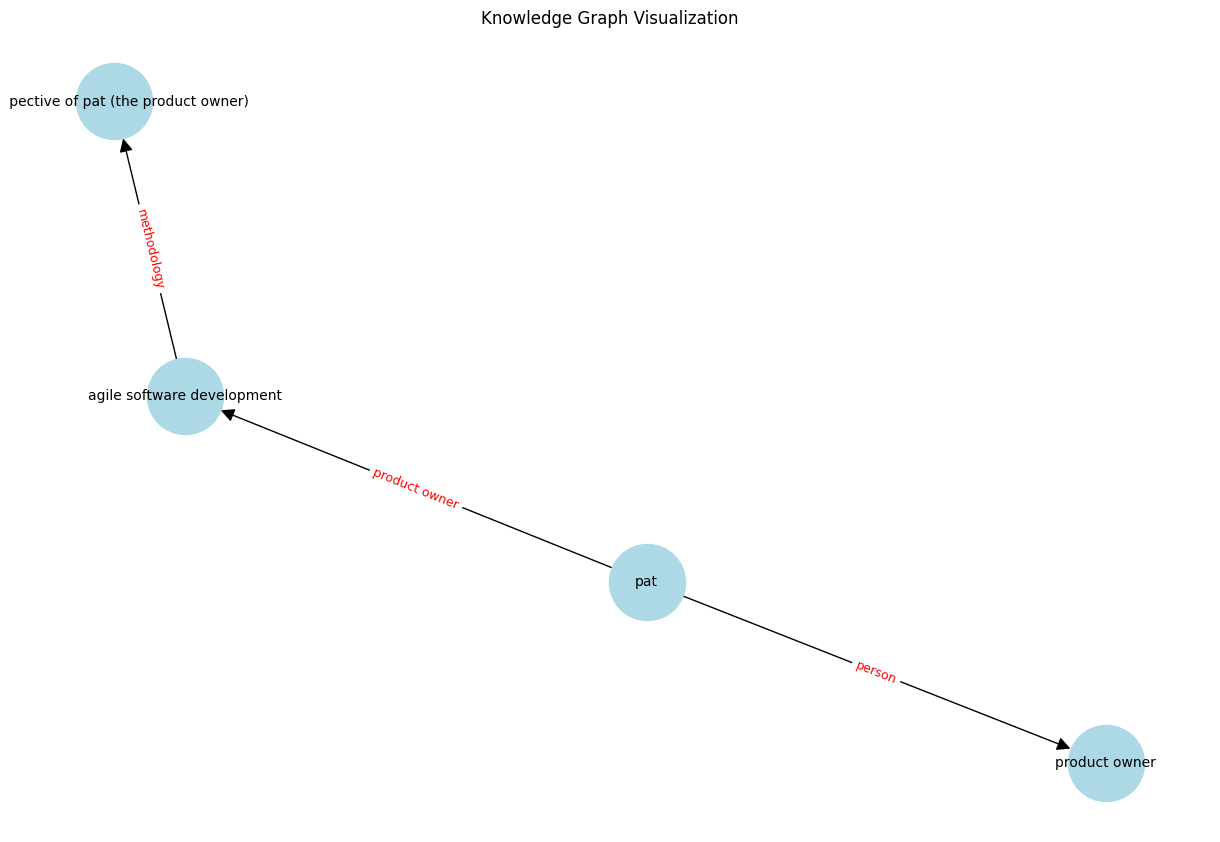

In [154]:
if __name__ == "__main__":
    main()
